In [2]:
import pandas as pd
from sklearn.datasets import load_iris
# pip install scikit-learn matplotlib  seaborn plotly

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Exploratory Data Analysis

In [4]:
df.species.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
# statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# checking for missing values
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


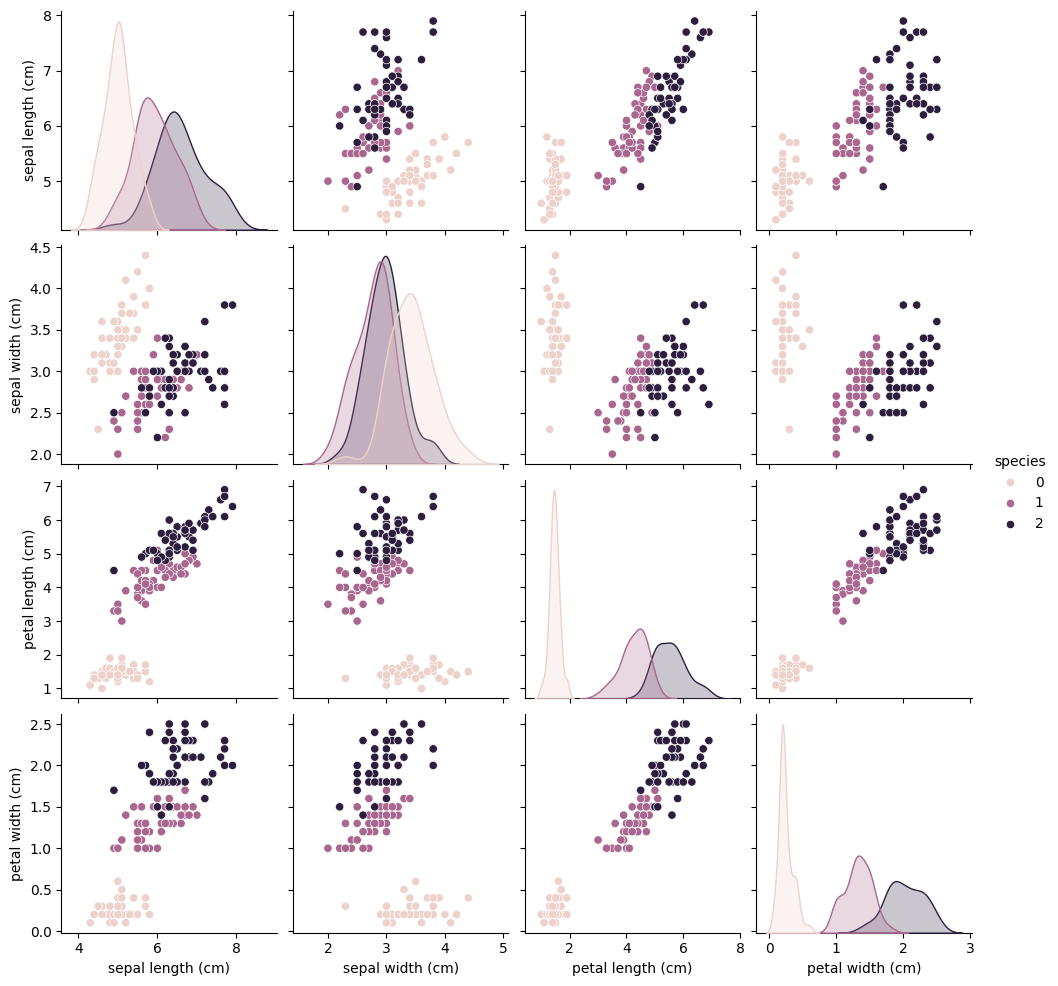

In [11]:
import sys
!{sys.executable} -m pip install seaborn
# visualizing feature distributions
import matplotlib.pyplot as plt
import seaborn as sns
# sns.pairplot creates a grid of scatter plots comparing each numeric feature against every other feature.
# Points are colored by species, making it easy to see how the species cluster in different feature combinations.
# Along the diagonal, you’ll see histograms of each feature, also colored by species.
sns.pairplot(df, hue="species")
plt.show()

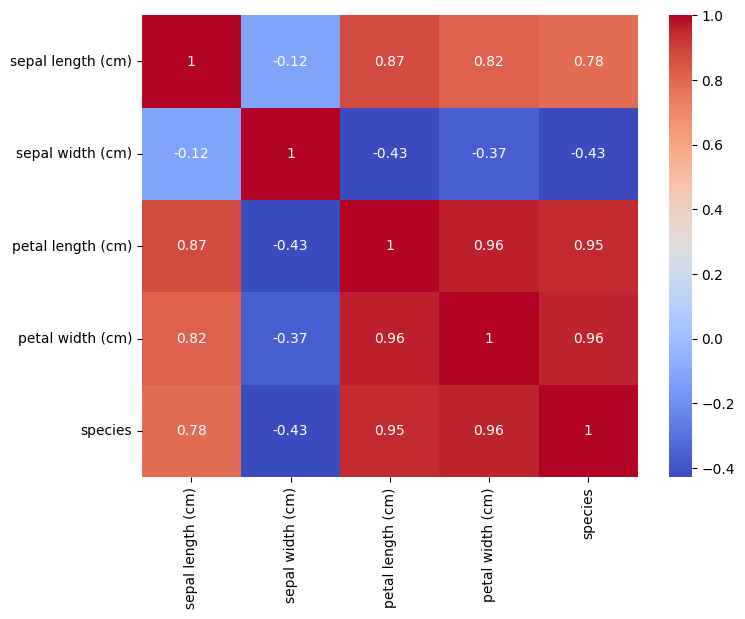

In [ ]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Data Preprocessing

In [ ]:
# standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[iris.feature_names])

df_scaled = pd.DataFrame(scaled_features, columns=iris.feature_names)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [ ]:
df_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [ ]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
normalized = mm.fit_transform(df[iris.feature_names])
df_normalized = pd.DataFrame(normalized, columns=iris.feature_names)
df_normalized.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [ ]:
df_normalized.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
# binning
df["sepal_length_bin"] = pd.cut(df["sepal length (cm)"], bins=3, labels=["short", "medium", "long"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_bin
0,5.1,3.5,1.4,0.2,0,short
1,4.9,3.0,1.4,0.2,0,short
2,4.7,3.2,1.3,0.2,0,short
3,4.6,3.1,1.5,0.2,0,short
4,5.0,3.6,1.4,0.2,0,short


In [ ]:
df[df.sepal_length_bin=="short"]["sepal length (cm)"].describe()

count    59.000000
mean      5.018644
std       0.319738
min       4.300000
25%       4.800000
50%       5.000000
75%       5.200000
max       5.500000
Name: sepal length (cm), dtype: float64

In [ ]:
df[df.sepal_length_bin=="medium"]["sepal length (cm)"].describe()

count    71.000000
mean      6.136620
std       0.352639
min       5.600000
25%       5.800000
50%       6.100000
75%       6.400000
max       6.700000
Name: sepal length (cm), dtype: float64

In [ ]:
df[df.sepal_length_bin=="long"]["sepal length (cm)"].describe()

count    20.000000
mean      7.235000
std       0.367459
min       6.800000
25%       6.900000
50%       7.200000
75%       7.625000
max       7.900000
Name: sepal length (cm), dtype: float64

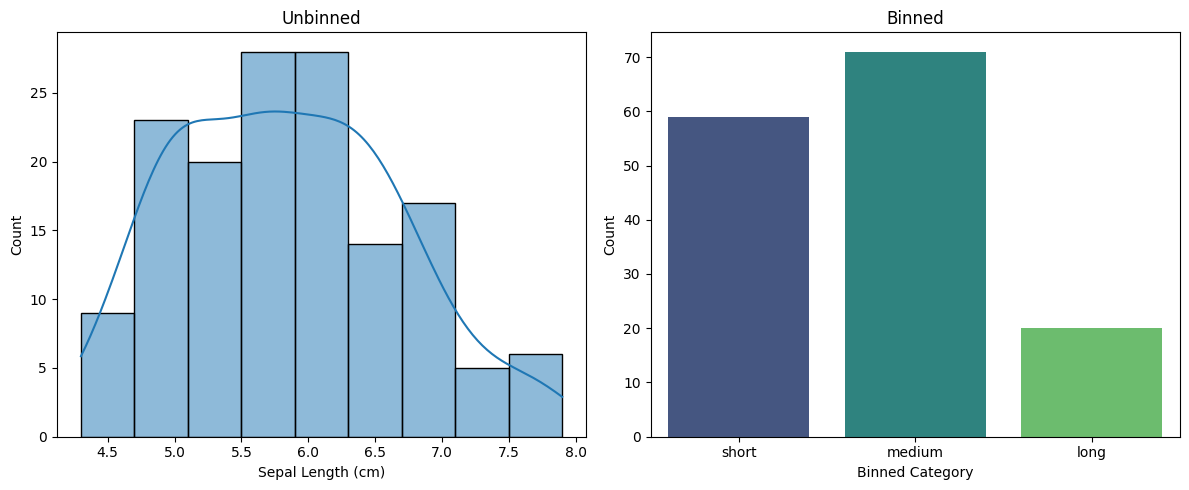

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unbinned continuous distribution
sns.histplot(df["sepal length (cm)"], kde=True, ax=axes[0])
axes[0].set_title("Unbinned")
axes[0].set_xlabel("Sepal Length (cm)")

# Binned categorical distribution
sns.countplot(x=df["sepal_length_bin"], ax=axes[1], palette="viridis", hue=df["sepal_length_bin"], legend=False)
axes[1].set_title("Binned")
axes[1].set_xlabel("Binned Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# one-hot encoding
df_encoded = pd.get_dummies(df, columns=["sepal_length_bin"])
df_encoded.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal_length_bin_short,sepal_length_bin_medium,sepal_length_bin_long
0,5.1,3.5,1.4,0.2,0,True,False,False
1,4.9,3.0,1.4,0.2,0,True,False,False
2,4.7,3.2,1.3,0.2,0,True,False,False
3,4.6,3.1,1.5,0.2,0,True,False,False
4,5.0,3.6,1.4,0.2,0,True,False,False


#### Feature Engineering

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[iris.feature_names])

pd.DataFrame(poly_features).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,5.1,3.5,1.4,0.2,26.01,17.85,7.14,1.02,12.25,4.90,0.70,1.96,0.28,0.04
1,4.9,3.0,1.4,0.2,24.01,14.70,6.86,0.98,9.00,4.20,0.60,1.96,0.28,0.04
2,4.7,3.2,1.3,0.2,22.09,15.04,6.11,0.94,10.24,4.16,0.64,1.69,0.26,0.04
3,4.6,3.1,1.5,0.2,21.16,14.26,6.90,0.92,9.61,4.65,0.62,2.25,0.30,0.04
4,5.0,3.6,1.4,0.2,25.00,18.00,7.00,1.00,12.96,5.04,0.72,1.96,0.28,0.04


In [ ]:
# log transformation
import numpy as np
df_log = df[iris.feature_names].apply(lambda x: np.log(x + 1))
df_log.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1.808289,1.504077,0.875469,0.182322
1,1.774952,1.386294,0.875469,0.182322
2,1.740466,1.435085,0.832909,0.182322
3,1.722767,1.410987,0.916291,0.182322
4,1.791759,1.526056,0.875469,0.182322


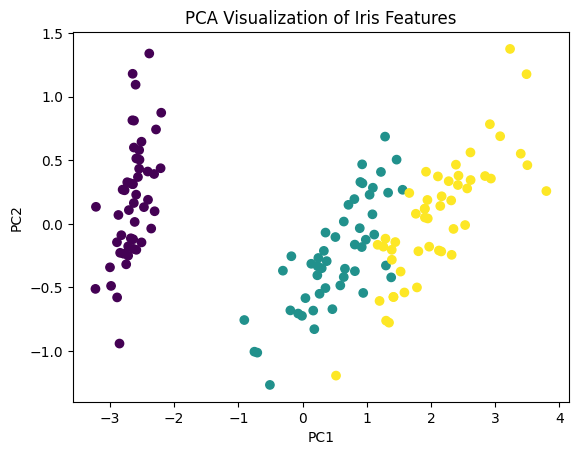

In [ ]:
# dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[iris.feature_names])

plt.scatter(pca_result[:,0], pca_result[:,1], c=df["species"], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Iris Features")
plt.show()

**Exercise**
1. Create box plots for each numerical feature in the Iris dataset. Identify potential outliers. How would you deal with them?
2. Randomly convert 10% of the values in two numeric features to missing values. Plot a stacked bar chart showing the number of present and missing values for each feature. Apply two different treatments to the missing values: mean imputation and median imputation. Compare the before/after distributions.
3. Plot side-by-side histograms for one feature after scaling (both standardization and normalization).
4. Create two engineered features. The first feature is a ratio of petal length to sepal length, and the second feature is an interaction term: sepal_width × petal_width. Add them to the dataset and use PCA with 2 components to visualize whether the new features help cluster species better.

In [ ]:
#Part 1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris(as_frame=True)
df = iris.frame

# Boxplots for numerical features
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:, :4])
plt.title("Boxplots of Iris Numerical Features")
plt.show()

# Identify potential outliers using IQR
for col in df.columns[:4]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} outliers:", len(outliers))

# Handling outliers (example: removing them)
# df_clean = df[~((df[col] < lower) | (df[col] > upper))]

In [ ]:
#Part 2
import numpy as np

df_missing = df.copy()

# Randomly introduce missing values (10%) in two features
features = ["sepal length (cm)", "petal length (cm)"]

for col in features:
    df_missing.loc[df_missing.sample(frac=0.1).index, col] = np.nan

# Plot stacked bar chart of missing vs present
missing_counts = df_missing.isna().sum()
present_counts = df_missing.notna().sum()

plot_df = pd.DataFrame({
    "Present": present_counts,
    "Missing": missing_counts
})

plot_df.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Present vs Missing Values")
plt.show()

# Mean imputation
df_mean = df_missing.fillna(df_missing.mean())

# Median imputation
df_median = df_missing.fillna(df_missing.median())

# Compare distributions
for col in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col], label="Original")
    sns.kdeplot(df_mean[col], label="Mean Imputed")
    sns.kdeplot(df_median[col], label="Median Imputed")
    plt.title(f"Distribution Comparison for {col}")
    plt.legend()
    plt.show()

In [ ]:
#Part 3
from sklearn.preprocessing import StandardScaler, MinMaxScaler

feature = df[["petal length (cm)"]]

# Standardization
scaler_std = StandardScaler()
standardized = scaler_std.fit_transform(feature)

# Normalization
scaler_norm = MinMaxScaler()
normalized = scaler_norm.fit_transform(feature)

# Plot histograms
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(standardized, bins=15)
plt.title("Standardized Feature")

plt.subplot(1,2,2)
plt.hist(normalized, bins=15)
plt.title("Normalized Feature")

plt.show()

In [ ]:
#Part 4
from sklearn.decomposition import PCA

df_features = df.copy()

# Create engineered features
df_features["petal_sepal_ratio"] = df_features["petal length (cm)"] / df_features["sepal length (cm)"]
df_features["width_interaction"] = df_features["sepal width (cm)"] * df_features["petal width (cm)"]

# PCA with 2 components
X = df_features.drop(columns="target")
y = df_features["target"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1")
plt.title("PCA Visualization with Engineered Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()